# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE)

## Notebook p02-08: UBFC-Phys Ensemble rPPG Extraction

### What this notebook does

Extracts rPPG signals from all 56 UBFC-Phys subjects (3 tasks each: T1=rest, T2=speech stress, T3=arithmetic stress) using a **three-algorithm ensemble** (POS, CHROM, GREEN), producing `ubcf_phys_ensemble.h5`.

### Pipeline 

```
{sid}/vid_{sid}_{task}.avi  (35.14 fps, 1024x1024)
    │
    ├─ 1  BGR -> RGB
    ├─ 2  MediaPipe Face Mesh -> ROI masks (forehead, left cheek, right cheek)
    └─ 3  Spatial mean RGB per ROI -> roi_rgb [T, 3_ROIs, 3_ch]
               │
               ├─ 4a  POS algorithm -> rppg_pos   [T]
               ├─ 4b  CHROM algorithm -> rppg_chrom [T]
               └─ 4c  GREEN mean -> rppg_green [T]
                         │
                         ├─ 5  Bandpass 0.7–3.5 Hz + z-score (all three)
                         ├─ 6  Spectral SQI: peak/band power ratio (all three)
                         └─ 7  Quality-weighted ensemble -> rppg_ensemble [T]

{sid}/bvp_{sid}_{task}.csv (64 Hz, raw ADC):
    z-score -> bandpass 0.5-8 Hz -> nk.ppg_clean -> peaks
    -> RR intervals -> HRV + BVP SQI
    -> hr_continuous at video fps (build_hr_continuous, same as NB06)
    -> reference_signal (resample_poly 64 Hz -> 35.14 fps)

 8  Gate: BVP SQI >= 0.5 AND ensemble SQI >= 0.07
 9  Write to ubfc_phys_ensemble.h5
```

### SQI gate rationale

BVP SQI = `1 - CV(RR_BVP)` - identical formula to ECG SQI (NB06) and PPG SQI (NB07).
Threshold 0.5: UBFC-Phys wristband BVP in lab conditions should be clean.
Ensemble SQI threshold 0.07 - same calibration as NB06/NB07.

In [ ]:
# UBFC-Phys data quality note:
# RMSSD labels for T2/T3 tasks are unreliable — wristband BVP motion artifacts
# during stress tasks inflate RMSSD artifactually (43.7% of recordings > 300ms).
# HR labels are unaffected (mean of RR intervals is robust to occasional jitter).
# Do not use UBFC-Phys RMSSD attrs as HRV training targets.
# Reliable HRV labels: MCD-rPPG (ECG-derived), ECG-Fitness (pending NB09).

## 1. Environment Setup

In [1]:
import subprocess, sys

packages = [
    "neurokit2",
    "mediapipe",
    "h5py",
    "opencv-python",
    "scipy",
    "numpy",
    "pandas",
    "matplotlib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages confirmed.")

All packages confirmed.


## 2. Imports

In [2]:
import os, warnings, cv2, h5py, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from pathlib import Path
from scipy.signal import butter, filtfilt, resample_poly
from math import gcd
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor" : "#1a1a2e",
    "axes.edgecolor" : "#444444",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color"  : "#e0e0e0",
    "ytick.color" : "#e0e0e0",
    "text.color" : "#e0e0e0",
    "grid.color" : "#2a2a3e",
    "grid.linestyle" : "--",
    "grid.alpha" : 0.5,
    "figure.dpi" : 110,
})

DATASET_ROOT = "F:/UBFC_PHYS_dataset"  
OUTPUT_DIR = "E:/QualityPhys"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Dataset root : {DATASET_ROOT}")
print(f"Output dir : {OUTPUT_DIR}")

Dataset root : F:/UBFC_PHYS_dataset
Output dir : E:/QualityPhys


## 3. Data Exploration

Computes `bvp_fs_actual` and `fps_actual` from real data. 

In [3]:
root = Path(DATASET_ROOT)
subject_dirs = sorted([d for d in root.iterdir() if d.is_dir() and d.name.startswith("s")], key=lambda d: int(d.name[1:]))
TASK_ALL = ["T1", "T2", "T3"]

print("=" * 60)
print("Dataset overview")
print("=" * 60)
print(f"Subject folders found: {len(subject_dirs)}")
print(f"Expected task per subject: {TASK_ALL}")

# BVP format and sampling rate
print()
print("=" * 60)
print("BVP .csv format + sampling rate (computed from data)")
print("=" * 60)

s0 = subject_dirs[0]
sid0 = s0.name
bvp0 = pd.read_csv(s0 / f"bvp_{sid0}_T1.csv", header=None).iloc[:, 0].values.astype(np.float64)
n_samp = len(bvp0)
# Duration from dataset README: 180 s per task
# Compute fs directly from sample count + know protocol duration
bvp_duration_s = 180.0
bvp_fs_actual = n_samp / bvp_duration_s

print(f"First subject : {sid0}")
print(f"BVP samples : {n_samp}")
print(f"Protocol duration : {bvp_duration_s:.0f}s (fixed by dataset protocol)")
print(f"BVP_FS computed : {bvp_fs_actual:.3f} Hz ({n_samp} / {bvp_duration_s:.0f})")
print(f"BVP amplitude : min={bvp0.min():.3f} max={bvp0.max():.3f} (raw ADC - needs z-score)")
print(f"BVP NaN/inf : nan={np.sum(np.isnan(bvp0))} inf={np.sum(np.isinf(bvp0))}")

# Video FPS from header
print()
print("=" * 60)
print("Video FPS from actual header (first subject/T1)")
print("=" * 60)

vpath0 = s0 / f"vid_{sid0}_T1.avi"
cap0 = cv2.VideoCapture(str(vpath0))
fps_probe = cap0.get(cv2.CAP_PROP_FPS)
w_probe = int(cap0.get(cv2.CAP_PROP_FRAME_WIDTH))
h_probe = int(cap0.get(cv2.CAP_PROP_FRAME_HEIGHT))
nf_probe = int(cap0.get(cv2.CAP_PROP_FRAME_COUNT))
cap0.release()

print(f"FPS from header: {fps_probe:.4f} Hz")
print(f"Resolution : {w_probe}x{h_probe}")
print(f"n_frames : {nf_probe}")
print(f"Duration : {nf_probe / fps_probe:.2f}s")

# Sanity: FPS should be consistent across all subjects
fps_sample = [] 
for s in subject_dirs[:10]:
    sid = s.name
    vp = s / f"vid_{sid}_T1.avi"
    if vp.exists():
        cap = cv2.VideoCapture(str(vp))
        f = cap.get(cv2.CAP_PROP_FPS)
        cap.release()
        if f > 0:
            fps_sample.append(f)

fps_arr = np.array(fps_sample)
print(f"\nFPS check (first 10 subjects/T1):")
print(f"mean={fps_arr.mean():.4f} std={fps_arr.std():.5f} min={fps_arr.min():.4f} max={fps_arr.max():.4f}")
print(f"Variation < 0.01 Hz: {(np.abs(fps_arr - fps_arr.mean()) < 0.01).all()}")

fps_actual = float(fps_probe)

# Info file format
print()
print("=" * 60)
print("Info file format (positional line parsing)")
print("=" * 60)
for s in subject_dirs[:3]:
    sid = s.name
    print(f"\n--- {sid} ---")
    print(open(s / f"info_{sid}.txt").read().strip())


# Anxiety file format
print()
print("=" * 60)
print("Anxiety file format (3x2 matrix)")
print("=" * 60)
anx0 = pd.read_csv(s0 / f"selfReportedAnx_{sid0}.csv", header=None)
print(f"Shape: {anx0.shape}")
print(f"Values: \n{anx0.to_string()}")
print("Layout : rows=[cognitive, somatic, self-confidence]  cols=[pre, post]")

# Resample ratio for BVP -> video fps
print()
print("=" * 60)
print("Summary — values that feed into Configuration cell")
print("=" * 60)
print(f"bvp_fs_actual : {bvp_fs_actual:.4f} Hz")
print(f"fps_actual : {fps_actual:.4f} Hz")
print(f"Resample ration BVP -> video : {fps_actual:.4f} / {bvp_fs_actual:.4f} = {fps_actual/bvp_fs_actual:.6f}")
print(f"(BVP downsampled from {bvp_fs_actual:.0f} Hz to {fps_actual:.3f} Hz for frame alignment)")

Dataset overview
Subject folders found: 56
Expected task per subject: ['T1', 'T2', 'T3']

BVP .csv format + sampling rate (computed from data)
First subject : s1
BVP samples : 11520
Protocol duration : 180s (fixed by dataset protocol)
BVP_FS computed : 64.000 Hz (11520 / 180)
BVP amplitude : min=-362.460 max=250.130 (raw ADC - needs z-score)
BVP NaN/inf : nan=0 inf=0

Video FPS from actual header (first subject/T1)
FPS from header: 35.1380 Hz
Resolution : 1024x1024
n_frames : 6326
Duration : 180.03s

FPS check (first 10 subjects/T1):
mean=35.1380 std=0.00000 min=35.1380 max=35.1380
Variation < 0.01 Hz: True

Info file format (positional line parsing)

--- s1 ---
s1
m
test
2019_02_07
11_37_06

--- s2 ---
s2
m
ctrl
2019-02-08
10-36-48

--- s3 ---
s3
f
ctrl
2019_02_08
11_18_55

Anxiety file format (3x2 matrix)
Shape: (3, 2)
Values: 
       0      1
0  2.143  3.286
1  2.571  3.428
2  2.778  1.778
Layout : rows=[cognitive, somatic, self-confidence]  cols=[pre, post]

Summary — values that f

## 4. Configuration 

In [4]:
DATASET_NAME = "ubfc_phys_ensemble"
HDF5_PATH = os.path.join(OUTPUT_DIR, "ubfc_phys_ensemble.h5")
MP_MODEL_PATH = os.path.join(OUTPUT_DIR, "face_landmarker.task")

# Tasks
TASKS = ["T1", "T2", "T3"]
TASK_NAMES = {"T1" : "rest", "T2" : "speech_stress", "T3" : "arithmetic_stress"}

# Sampling rates  
BVP_FS = bvp_fs_actual # 64.0 Hz (computed: 11520 / 180)
FPS_FALLBACK = fps_actual # 35.138 Hz (from video header)

# Signal processing — identical to NB06/NB07
RPPG_BP_LOW, RPPG_BP_HIGH  = 0.7, 3.5
BVP_BP_LOW, BVP_BP_HIGH = 0.5, 8.0
BUTTER_ORDER = 4

# SQI gates
RPPG_SQI_THRESHOLD = 0.05 # ensemble spectral SQI - lowered for UBFC-Phys stress/motion variability, Previously 0.07, which rejected many valid T2/T3 stress recordings.
# UBFC-Phys has lower spectral SQI due to: 35 fps FFT spread, smaller effective face ROI at 1024x1024, real motion during stress task.
# Gate affects only HDF5 inclusion, not signal validity or training directly.
RPPG_SQI_MIN_FLOOR = 0.01 # weight floor for ensemble
BVP_SQI_THRESHOLD  = 0.5 # BVP SQI = 1 - CV(RR_BVP) 

# Face detection
NO_FACE_THRESHOLD = 20.0 # % frames 

# HR physiological limits
HR_MIN = 40
HR_MAX = 200

# Algorithms
ALGORITHMS  = ["pos", "chrom", "green"]
HDF5_SKIP_KEY = "rppg_ensemble"

# ROI landmark indices — identical to NB06/NB07
FOREHEAD_LM = [10,338,297,332,284,251,389,356,454,
               323,361,288,397,365,379,378,400,377,
               152,148,176,149,150,136,172,58, 132,
               93, 234,127,162,21, 54, 103,67, 109]
LEFT_CHEEK_LM  = [234,227,116,123,147,213,192,214,210,
                  211,206,203,36, 101,119,229,228]
RIGHT_CHEEK_LM = [454,447,345,352,376,433,416,434,430,
                  431,426,423,266,330,348,449,448]
ROI_CONFIGS = {"forehead" : FOREHEAD_LM, "left_cheek" : LEFT_CHEEK_LM, "right_cheek" : RIGHT_CHEEK_LM}

print("NB_P2_08 configuration loaded.")
print(f"Output HDF5 : {HDF5_PATH}")
print(f"Tasks : {TASKS}")
print(f"Task names : {TASK_NAMES}")
print(f"BVP_FS : {BVP_FS:.4f} Hz  (computed from data)")
print(f"FPS_FALLBACK : {FPS_FALLBACK:.4f} Hz  (from video header)")
print(f"rPPG band : {RPPG_BP_LOW}–{RPPG_BP_HIGH} Hz")
print(f"Algorithms : {ALGORITHMS}")
print(f"Ensemble SQI >= : {RPPG_SQI_THRESHOLD}")
print(f"BVP SQI >= : {BVP_SQI_THRESHOLD}")
print(f"No-face threshold : {NO_FACE_THRESHOLD}%")


NB_P2_08 configuration loaded.
Output HDF5 : E:/QualityPhys\ubfc_phys_ensemble.h5
Tasks : ['T1', 'T2', 'T3']
Task names : {'T1': 'rest', 'T2': 'speech_stress', 'T3': 'arithmetic_stress'}
BVP_FS : 64.0000 Hz  (computed from data)
FPS_FALLBACK : 35.1380 Hz  (from video header)
rPPG band : 0.7–3.5 Hz
Algorithms : ['pos', 'chrom', 'green']
Ensemble SQI >= : 0.05
BVP SQI >= : 0.5
No-face threshold : 20.0%


## 5. Build Recording Inventory

In [5]:
def build_inventory(dataset_root: str) -> pd.DataFrame:
    """
    Scan dataset_root for all subject folders.
    Each subject has 3 tasks (T1, T2, T3), each with one video + one BVP CSV.
    Checks HDF5 for already-completed recordings to enable resume.
    Resume key: (subject_name, task)
    """
    root = Path(dataset_root)
    records = []

    for subject_dir in sorted([d for d in root.iterdir() if d.is_dir() and d.name.startswith("s")], key=lambda d: int(d.name[1:])):
        sid = subject_dir.name

        for task in TASKS:
            video_path = subject_dir / f"vid_{sid}_{task}.avi"
            bvp_path = subject_dir / f"bvp_{sid}_{task}.csv"
            info_path = subject_dir / f"info_{sid}.txt"
            anx_path = subject_dir / f"selfReportedAnx_{sid}.csv"

            has_video = video_path.exists() and video_path.stat().st_size > 0
            has_bvp = bvp_path.exists()

            # FPS from actual video header 
            fps = FPS_FALLBACK
            if has_video:
                cap = cv2.VideoCapture(str(video_path))
                fps_header = cap.get(cv2.CAP_PROP_FPS)
                cap.release()
                if fps_header > 0:
                    fps = fps_header

            records.append({
                "subject_name" : sid,
                "task" : task,
                "activity_name" : TASK_NAMES[task],
                "video_path" : str(video_path) if has_video else None,
                "bvp_path" : str(bvp_path) if has_bvp else None,
                "info_path" : str(info_path) if info_path.exists() else None,
                "anx_path" : str(anx_path) if anx_path.exists() else None,
                "fps" : fps,
                "has_video" : has_video,
                "has_bvp" : has_bvp,
            })

    df = pd.DataFrame(records)

    # HDF5 completion flag
    df["done"] = False
    if os.path.exists(HDF5_PATH):
        with h5py.File(HDF5_PATH, "r") as hf:
            for i, row in df.iterrows():
                hdf5_key = f"subjects/{row['subject_name']}/recordings/{row['task']}"
                if hdf5_key in hf:
                    df.at[i, "done"] = True

    return df.sort_values(["subject_name", "task"], key=lambda col: col.map(lambda x: int(x[1:]) if col.name == "subject_name" else x)).reset_index(drop=True)


df_inventory = build_inventory(DATASET_ROOT)

print(f"Total recordings : {len(df_inventory)} ({len(df_inventory)//3} subjects x 3 tasks)")
print(f"Videos found : {df_inventory['has_video'].sum()}")
print(f"BVP files found : {df_inventory['has_bvp'].sum()}")
print(f"Already done : {df_inventory['done'].sum()}")
print(f"Remaining : {(df_inventory['has_video'] & df_inventory['has_bvp'] & ~df_inventory['done']).sum()}")
print()
print("Per-task breakdown:")
print(df_inventory.groupby("task")[["has_video","has_bvp","done"]].sum())
print()
fps_arr = df_inventory["fps"].dropna()
print(f"FPS distribution: mean={fps_arr.mean():.4f} std={fps_arr.std():.5f} min={fps_arr.min():.4f} max={fps_arr.max():.4f}")
print()
print(df_inventory[["subject_name","task","fps","has_video","has_bvp","done"]].to_string())

Total recordings : 168 (56 subjects x 3 tasks)
Videos found : 168
BVP files found : 168
Already done : 0
Remaining : 168

Per-task breakdown:
      has_video  has_bvp  done
task                          
T1           56       56     0
T2           56       56     0
T3           56       56     0

FPS distribution: mean=35.1380 std=0.00000 min=35.1380 max=35.1380

    subject_name task     fps  has_video  has_bvp   done
0             s1   T1  35.138       True     True  False
1             s1   T2  35.138       True     True  False
2             s1   T3  35.138       True     True  False
3             s2   T1  35.138       True     True  False
4             s2   T2  35.138       True     True  False
5             s2   T3  35.138       True     True  False
6             s3   T1  35.138       True     True  False
7             s3   T2  35.138       True     True  False
8             s3   T3  35.138       True     True  False
9             s4   T1  35.138       True     True  False
10     

## 6. Subject Metadata Loaders

Info file (gender, scenario) and anxiety scores

In [6]:
def load_subject_info(info_path: str) -> dict:
    """
    Parse info_{sid}.txt - positional line format:
        line 0: subject_id (e.g. 's1')
        line 1: gender ('m' or 'f')
        line 2: scenario ('test' or 'ctrl')
        line 3: date (YYYY_MM_DD or YYYY-MM-DD)
        line 4: time (hh_mm_ss or hh-mm-ss)
    """
    result = {"gender" : "?", "scenario" : "?" , "date" : "?", "time" : "?"}
    if not info_path or not os.path.exists(info_path):
        return result
    try:
        lines = [l.strip() for l in open(info_path).read().strip().split("\n") if l.strip()]
        if len(lines) >= 2:
            result["gender"] = lines[1].strip().lower()
        if len(lines) >= 3:
            result["scenario"] = lines[2].strip().lower()
        if len(lines) >= 4:
            result["date"] = lines[3].strip()
        if len(lines) >= 5: 
            result["time"] = lines[4].strip()
    except Exception as e:
        print(f"[WARN] info parse error {info_path} : {e}")
    return result
        

def load_anxiety_scores(anx_path: str) -> dict:
    """
    Parse selfReportedAnx_{sid}.csv - confirmed 3x2 matrix:
        row 0: cognitive anxiety [pre, post]
        row 1: somatic anxiety [pre, post]
        row 2: self-confidence [pre, post]
    Sentinel -1.0 for missing/parse error.
    """
    nan_result = {
        "anx_cognitive_pre" : -1.0,
        "anx_cognitive_post" : -1.0,
        "anx_somatic_pre" : -1.0,
        "anx_somatic_post" : -1.0,
        "anx_confidence_pre" : -1.0,
        "anx_confidence_post" : -1.0,
    }
    if not anx_path or not os.path.exists(anx_path):
        return nan_result
    try:
        df_anx = pd.read_csv(anx_path, header=None)
        if df_anx.shape  != (3, 2):
            print(f"[WARN] Unexpected anxiety shape {df_anx.shape} in {anx_path}")
            return nan_result
        return {
            "anx_cognitive_pre" : float(df_anx.iloc[0, 0]),
            "anx_cognitive_post" : float(df_anx.iloc[0, 1]),
            "anx_somatic_pre" : float(df_anx.iloc[1, 0]),
            "anx_somatic_post" : float(df_anx.iloc[1, 1]),
            "anx_confidence_pre" : float(df_anx.iloc[2, 0]),
            "anx_confidence_post": float(df_anx.iloc[2, 1]),
        }
    except Exception as e:
        print(f"[WARN] Anxiety parse error {anx_path}: {e}")
        return nan_result


# Sanity check
test_row = df_inventory.iloc[0]
info = load_subject_info(test_row["info_path"])
anxiety = load_anxiety_scores(test_row["anx_path"])
print(f"Subject metadata loader sanity: {test_row['subject_name']}")
print(f"gender : {info['gender']}")
print(f"scenario : {info['scenario']}")
print(f"date : {info['date']}")
for key, value in anxiety.items():
    print(f"{key:<24} : {value}")
print()
print("Subject metadata loaders defined.")

Subject metadata loader sanity: s1
gender : m
scenario : test
date : 2019_02_07
anx_cognitive_pre        : 2.143
anx_cognitive_post       : 3.286
anx_somatic_pre          : 2.571
anx_somatic_post         : 3.428
anx_confidence_pre       : 2.778
anx_confidence_post      : 1.778

Subject metadata loaders defined.


## 7. Reference Signal Loaders

BVP at 64 Hz raw ADC -> z-score -> bandpass -> nk.ppg_clean -> peaks -> HRV + BVP SQI + hr_continuous at video fps.


In [7]:
def load_bvp(bvp_path: str):
    """
    Load UBFC-Phys BVP CSV.
    Single column, no header, raw ADC values.
    Returns float64 array or None
    """
    if not bvp_path or not os.path.exists(bvp_path):
        return None
    try:
        return pd.read_csv(bvp_path, header=None).iloc[:, 0].values.astype(np.float64)
    except Exception as e:
        print(f"[WARN] BVP load error {bvp_path} : {e}")
        return None


def detect_bvp_peaks(bvp_raw: np.ndarray, bvp_fs: float) -> tuple:
    """
    BVP peak detection pipeline.

    1. Z-score normalise - raw ADC values span wide range across subjects.
    2. Bandpass 0.5-8Hz (broad enough to preserve waveform morphology).
    3. nk.ppg_clean on the filtered, normalised signal.
    4. nk.ppg_peaks.
    Returns (peak_idx, rr_ms, hr_mean_bpm).
    """
    try:
        fs = int(round(bvp_fs))

        # Z-score
        bvp_z = (bvp_raw - bvp_raw.mean()) / (bvp_raw.std() + 1e-8)
        # Bandpass
        nyq = bvp_fs / 2.0
        b,a = butter(BUTTER_ORDER, [BVP_BP_LOW / nyq, BVP_BP_HIGH / nyq], btype="band")
        bvp_filt = filtfilt(b, a, bvp_z).astype(np.float32)

        # Neurokit
        bvp_clean = nk.ppg_clean(bvp_filt, sampling_rate=fs)
        peak_dict, _ = nk.ppg_peaks(bvp_clean, sampling_rate=fs)
        peak_idx = np.where(peak_dict["PPG_Peaks"] == 1)[0]

        if len(peak_idx) < 3:
            return peak_idx, np.array([]), float("nan")

        rr_ms = np.diff(peak_idx) / bvp_fs * 1000.0
        hr_mean = float(60000.0 / rr_ms.mean())
        return peak_idx, rr_ms, hr_mean

    except Exception  as e:
        print(f"[WARN] BVP peak detection failed: {e}")
        return np.array([]), np.array([]), float("nan")


def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """Time-domain HRV from RR intervals."""
    nan = {
        "mean_rr_ms" : float("nan"),
        "sdnn_ms" : float("nan"),
        "rmssd_ms" : float("nan"),
        "pnn50_pct" : float("nan"),
        "hr_mean_bpm" : float("nan"),
    }
    if len(rr_ms) < 3:
        return nan
    rr = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr) < 3:
        return nan
    diff = np.diff(rr)
    return {
        "mean_rr_ms" : float(rr.mean()),
        "sdnn_ms" : float(rr.std()),
        "rmssd_ms" : float(np.sqrt(np.mean(diff ** 2))),
        "pnn50_pct" : float((np.abs(diff) > 50).mean() * 100),
        "hr_mean_bpm" : float(60000.0 / rr.mean()),
    }



def compute_bvp_sqi(rr_ms: np.ndarray) -> float:
    """
    BVP SQI = 1 - CV(RR).
    Higher = more regular RR intervals = cleaner reference.
    """
    if len(rr_ms) < 3:
        return float("nan")
    rr = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr) < 3:
        return float("nan")
    cv = rr.std() / (rr.mean() + 1e-8)
    return float(1.0 - min(cv, 1.0))


def build_hr_continuous(peak_idx: np.ndarray, rr_ms: np.ndarray, source_fs: float, n_frames: int, target_fps: float) -> np.ndarray:
    """
    Build continuous HR array at video frame rate from BVP peaks.
    Maps each BVP peak (BVP samples at source_fs=64Hz) to the corresponding
    video frame (target_fps=35.14 Hz), then forward-fills.
    """
    hr_cont = np.full(n_frames, np.nan, dtype=np.float32)
    if len(peak_idx) < 2 or len(rr_ms) == 0:
        return hr_cont
    for i, idx in enumerate(peak_idx[:-1]):
        fi = int(idx / source_fs * target_fps)
        if 0 <= fi < n_frames:
            hr_cont[fi] = 60000.0 / rr_ms[i]
    last = np.nan
    for i in range(n_frames):
        if not np.isnan(hr_cont[i]):
            last = hr_cont[i]
        elif not np.isnan(last):
            hr_cont[i] = last
    return hr_cont


def resample_bvp_to_video(bvp: np.ndarray, bvp_fs: float, n_video_frames: int, video_fps: float) -> np.ndarray:
    """
    Downsample BVP from bvp_fs (64Hz) to video_fps (35.14 Hz).
    Uses resample_poly for correct waveform shape preservation.
    Result trimmed/padded to exactly n_video_frames.
    """
    up = int(round(video_fps * 1000))
    down = int(round(bvp_fs * 1000))
    g = gcd(up, down)
    resampled = resample_poly(bvp, up // g, down // g)
    if len(resampled) >= n_video_frames:
        return resampled[:n_video_frames].astype(np.float32)
    pad = np.full(n_video_frames - len(resampled), resampled[-1], dtype=np.float32)
    return np.concatenate([resampled, pad]).astype(np.float32)



# Sanity check
print("Reference signal functions defined.")
print()
print("Sanity check: s1/T1")
test_row = df_inventory[(df_inventory["subject_name"]=="s1") & (df_inventory["task"]=="T1")].iloc[0]
bvp_raw = load_bvp(test_row["bvp_path"])
if bvp_raw is not None:
    peak_idx, rr_ms, hr_mean = detect_bvp_peaks(bvp_raw, BVP_FS)
    hrv = compute_hrv_features(rr_ms)
    bvp_sqi = compute_bvp_sqi(rr_ms)
    hr_cont = build_hr_continuous(peak_idx, rr_ms, BVP_FS, 300, FPS_FALLBACK)
    print(f"BVP samples : {len(bvp_raw)} range=[{bvp_raw.min():.1f}, {bvp_raw.max():.1f}]")
    print(f"BVP peaks : {len(peak_idx)} RR mean={rr_ms.mean():.1f} ms HR={hr_mean:.1f} BPM")
    print(f"BVP SQI : {bvp_sqi:.3f}")
    print(f"RMSSD : {hrv['rmssd_ms']:.1f} ms SDNN={hrv['sdnn_ms']:.1f} ms")
    print(f"hr_cont[300]: min={np.nanmin(hr_cont):.1f} max={np.nanmax(hr_cont):.1f} NaN={np.sum(np.isnan(hr_cont))}")

Reference signal functions defined.

Sanity check: s1/T1
BVP samples : 11520 range=[-362.5, 250.1]
BVP peaks : 244 RR mean=734.4 ms HR=81.7 BPM
BVP SQI : 0.839
RMSSD : 83.7 ms SDNN=118.2 ms
hr_cont[300]: min=61.9 max=85.3 NaN=31


## 8. MediaPipe ROI Extraction

In [8]:
if not os.path.exists(MP_MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MP_MODEL_PATH)
    print("Downloaded.")
else:
    print(f"Face landmarker model present: {MP_MODEL_PATH}")


def get_roi_mask(landmarks, frame_shape: tuple, lm_indices: list) -> np.ndarray:
    """Binary polygon mask for one ROI from MediaPipe landmarks."""
    h, w = frame_shape[:2]
    pts = np.array([[int(landmarks[i].x * w), int(landmarks[i].y * h)] for i in lm_indices], dtype=np.int32)
    mask = np.zeros((h,w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def extract_roi_signals(video_path: str, roi_configs: dict, max_frames: int = None) -> dict:
    """
    Single-pass video extraction. 
    Returns roi_rgb [T, n_rois, 3], actual_fps, n_frames, no_face_pct.
    """
    cap = cv2.VideoCapture(video_path)
    actual_fps = cap.get(cv2.CAP_PROP_FPS)
    if actual_fps <= 0:
        actual_fps = FPS_FALLBACK

    roi_names = list(roi_configs.keys())
    roi_sigs = {name: [] for name in roi_names}
    n_frames = 0
    no_face = 0

    base_opts = mp_python.BaseOptions(model_asset_path=MP_MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_opts,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1,
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            ts_ms = int((n_frames / actual_fps) * 1000)
            result = landmarker.detect_for_video(mp_img, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb.shape, indices)
                    if mask.sum() > 0:
                        r = rgb[:, :, 0][mask == 1].mean()
                        g = rgb[:, :, 1][mask == 1].mean()
                        b = rgb[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r, g, b], dtype=np.float32))
                    else:
                        fb = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                        roi_sigs[name].append(fb)
            else:
                no_face += 1
                for name in roi_configs:
                    fb = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                    roi_sigs[name].append(fb)

            n_frames += 1

    cap.release()

    arrays = [np.array(roi_sigs[name]) for name in roi_names]
    roi_rgb = np.stack(arrays, axis=1).astype(np.float32)

    return {
        "roi_rgb" : roi_rgb,
        "actual_fps" : actual_fps,
        "n_frames" : n_frames,
        "no_face_pct": round(100 * no_face / max(n_frames, 1), 1),
    }


print("ROI extraction function defined.")

Face landmarker model present: E:/QualityPhys\face_landmarker.task
ROI extraction function defined.


## 9. rPPG Algorithms + Spectral SQI + Ensemble

In [9]:
def bandpass_filter(signal: np.ndarray, fps: float, low: float, high: float, order: int = 4) -> np.ndarray:
    """Zero-phase Butterworth bandpass."""
    nyq = fps / 2.0
    b,a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal).astype(np.float32)


def zscore(signal: np.ndarray) -> np.ndarray:
    """Zero-mean unit-variance normalisation."""
    mu, sigma = signal.mean(), signal.std() + 1e-8
    return ((signal - mu) / sigma).astype(np.float32)



def apply_pos(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """
    POS algorithm. Per ROI independently, then average.
    Cn = C / mean(C), S = P @ Cn.T, h = S[0] + alpha*S[1].
    """
    P = np.array([[0, 1, -1], [-2, 1, 1]], dtype=np.float64)
    n_rois = roi_rgb.shape[1]
    signals = []
    for r in range(n_rois):
        C = roi_rgb[:, r, :].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        S = P @ Cn.T
        h = S[0] + (S[0].std() / (S[1].std() + 1e-8)) * S[1]
        signals.append(h)
    combined = np.mean(signals, axis=0)
    return zscore(bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH))


def apply_chrom(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """
    CHROM algorithm. Per ROI independently, then average.
    Xs = 3R-2G, Ys = 1.5R+G-1.5B, H = Xs - alpha*Ys.
    """
    n_rois = roi_rgb.shape[1]
    signals = []
    for r in range(n_rois):
        C = roi_rgb[:, r, :].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        Xs = 3.0 * Cn[:, 0] - 2.0 * Cn[:, 1]
        Ys = 1.5 * Cn[:, 0] + Cn[:, 1] - 1.5 * Cn[:, 2]
        alpha = Xs.std() / (Ys.std() + 1e-8)
        signals.append(Xs - alpha * Ys)
    combined = np.mean(signals, axis=0)
    return zscore(bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH))


def apply_green(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """
    GREEN channel mean across ROIs.
    Oxyhaemoglobin absorption peak ~550 nm. No artefact rejection.
    """
    green = roi_rgb[:, :, 1].mean(axis=1)
    return zscore(bandpass_filter(green, fps, RPPG_BP_LOW, RPPG_BP_HIGH))


ALGORITHM_FN = {"pos": apply_pos, "chrom": apply_chrom, "green": apply_green}


def compute_spectral_sqi(signal: np.ndarray, fps: float) -> float:
    """
    Peak-to-band power ratio in cardiac band [0.7-3.5 Hz].
    SQI->1.0: near-sinusoidal. SQI->0.0: noise.
    """
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1.0 / fps)
    power = np.abs(np.fft.rfft(signal - signal.mean())) ** 2
    mask = (freqs >= RPPG_BP_LOW) & (freqs <= RPPG_BP_HIGH)
    band = power[mask]
    if band.sum() < 1e-10:
        return 0.0
    pk = np.argmax(band)
    lo = max(0, pk - 3)
    hi = min(len(band), pk + 4)
    return float(band[lo:hi].sum() / band.sum())


def compute_ensemble(signals: dict, sqis: dict) -> tuple:
    """
    Quality-proportional weighted sum. w_i = max(SQI_i, floor) / sum(w_j).
    """
    raw_w = np.array([max(sqis[a], RPPG_SQI_MIN_FLOOR) for a in ALGORITHMS], dtype=np.float64)
    weights = raw_w / raw_w.sum()
    stacked = np.stack([signals[a] for a in ALGORITHMS], axis=0)
    ensemble = (stacked * weights[:, None]).sum(axis=0).astype(np.float32)
    return ensemble, weights.astype(np.float32)


print("rPPG algorithm + SQI + ensemble functions defined.")
print(f"Algorithms : {ALGORITHMS}")
print("SQI type : spectral peak-to-band ratio")
print("Ensemble : quality-weighted soft fusion")

rPPG algorithm + SQI + ensemble functions defined.
Algorithms : ['pos', 'chrom', 'green']
SQI type : spectral peak-to-band ratio
Ensemble : quality-weighted soft fusion


## 10. Single-Recording Pipeline

Skip conditions: `gt_load_failed`, `flat_bvp`, `too_short`, `bvp_peak_failed`, `implausible_hr`, `bvp_sqi_low`, `no_face`, `ensemble_sqi_low`.

In [10]:
def process_single_recording(row: pd.Series, max_frames: int = None) -> tuple:
    """
    Full pipeline for one UBFC-Phys subject/task.
    Returns (result_dict, status_string). result_dict is None if skipped.
    """
    subject = row["subject_name"]
    task = row["task"]

    # Step 1: Load and validate BVP
    bvp_raw = load_bvp(row["bvp_path"])
    if bvp_raw is None:
        return None, "gt_load_failed"

    if bvp_raw.max() - bvp_raw.min() < 0.1:
        return None, "flat_bvp"

    if len(bvp_raw) < 240:
        return None, f"too_short ({len(bvp_raw)} samples)"

    # Step 2: BVP peak detection -> HRV + BVP SQI
    peak_idx, rr_ms, hr_mean_bvp = detect_bvp_peaks(bvp_raw, BVP_FS)

    if np.isnan(hr_mean_bvp):
        return None, "bvp_peak_failed"

    if hr_mean_bvp < HR_MIN or hr_mean_bvp > HR_MAX:
        return None, f"implausible_hr ({hr_mean_bvp:.1f} BPM)"

    bvp_sqi = compute_bvp_sqi(rr_ms)
    if not np.isnan(bvp_sqi) and bvp_sqi < BVP_SQI_THRESHOLD:
        return None, f"bvp_sqi_low ({bvp_sqi:.3f})"

    hrv = compute_hrv_features(rr_ms)

    # Step 3: Subject metadata
    info = load_subject_info(row["info_path"])
    anxiety = load_anxiety_scores(row["anx_path"])

    # Step 4: ROI extraction from video
    roi_out = extract_roi_signals(row["video_path"], ROI_CONFIGS, max_frames=max_frames)
    roi_rgb = roi_out["roi_rgb"]
    n_frames = roi_out["n_frames"]
    actual_fps = roi_out["actual_fps"]
    no_face = roi_out["no_face_pct"]

    if no_face > NO_FACE_THRESHOLD:
        return None, f"no_face ({no_face:.1f}%)"

    # Step 5: Three rPPG algorithms
    rppg_signals = {}
    rppg_sqis = {}
    for alg in ALGORITHMS:
        sig = ALGORITHM_FN[alg](roi_rgb, actual_fps)
        rppg_signals[alg] = sig
        rppg_sqis[alg] = compute_spectral_sqi(sig, actual_fps)

    # Step 6: Ensemble
    rppg_ensemble, ens_weights = compute_ensemble(rppg_signals, rppg_sqis)
    sqi_ensemble = compute_spectral_sqi(rppg_ensemble, actual_fps)

    if sqi_ensemble < RPPG_SQI_THRESHOLD:
        return None, f"ensemble_sqi_low ({sqi_ensemble:.3f})"

    # Step 7: Reference signal + hr_continuous at video fps
    reference_signal = resample_bvp_to_video(bvp_raw, BVP_FS, n_frames, actual_fps)
    hr_continuous = build_hr_continuous(peak_idx, rr_ms, BVP_FS, n_frames, actual_fps)

    # Step 8: Trim to shortest common length T
    T = min(n_frames, len(rppg_ensemble), len(reference_signal), len(hr_continuous), roi_rgb.shape[0])

    hr_mean = float(np.nanmean(hr_continuous[:T])) if not np.all(np.isnan(hr_continuous[:T])) else hr_mean_bvp
    rr_storage = rr_ms.astype(np.float32) if len(rr_ms) > 0 else np.array([], dtype=np.float32)

    sqis_str = " ".join(f"{a}={rppg_sqis[a]:.3f}" for a in ALGORITHMS)
    print(f"{subject}/{task} T={T} HR={hr_mean:.1f} bvp_sqi={bvp_sqi:.3f} "
          f"ens={sqi_ensemble:.3f} [{sqis_str}] no_face={no_face:.1f}% fps={actual_fps:.2f}")

    result = {
        # rPPG signals
        "rppg_pos" : rppg_signals["pos"][:T],
        "rppg_chrom" : rppg_signals["chrom"][:T],
        "rppg_green" : rppg_signals["green"][:T],
        "rppg_ensemble" : rppg_ensemble[:T],
        "ensemble_weights" : ens_weights,
        # Supporting signals
        "roi_rgb" : roi_rgb[:T],
        "reference_signal" : reference_signal[:T],
        "hr_continuous" : hr_continuous[:T],
        "rr_intervals" : rr_storage,
        # Scalar labels
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],
        # SQI
        "bvp_sqi" : float(bvp_sqi) if not np.isnan(bvp_sqi) else -1.0,
        "sqi_pos" : float(rppg_sqis["pos"]),
        "sqi_chrom" : float(rppg_sqis["chrom"]),
        "sqi_green" : float(rppg_sqis["green"]),
        "sqi_ensemble" : float(sqi_ensemble),
        # Metadata
        "subject_id" : subject,
        "activity_id" : task,
        "activity_name" : TASK_NAMES[task],
        "dataset" : DATASET_NAME,
        "reference_type" : "BVP_continuous",
        "n_frames" : T,
        "fps" : actual_fps,
        "no_face_pct" : float(no_face),
        # Subject attrs
        "gender" : info["gender"],
        "scenario" : info["scenario"],
        **anxiety,
    }
    return result, "ok"


print("process_single_recording defined.")


process_single_recording defined.


## 11. Single-Recording Demo (300 frames)

Demo: s1/T1 | fps=35.1380

s1/T1 T=300 HR=72.5 bvp_sqi=0.839 ens=0.573 [pos=0.647 chrom=0.879 green=0.726] no_face=0.0% fps=35.14

Signal shapes:
rppg_pos               : (300,) dtype=float32 nan=0
rppg_chrom             : (300,) dtype=float32 nan=0
rppg_green             : (300,) dtype=float32 nan=0
rppg_ensemble          : (300,) dtype=float32 nan=0
roi_rgb                : (300, 3, 3) dtype=float32 nan=0
reference_signal       : (300,) dtype=float32 nan=0
hr_continuous          : (300,) dtype=float32 nan=31
rr_intervals           : (243,) dtype=float32 nan=0
ensemble_weights       : (3,) dtype=float32 nan=0

Scalar labels:
hr_mean                  : 72.48621368408203
rmssd_ms                 : 83.71648637151802
sdnn_ms                  : 118.16613829567223
pnn50_pct                : 21.074380165289256
bvp_sqi                  : 0.8390929180676587
sqi_ensemble             : 0.5725334882736206
no_face_pct              : 0.0
fps                      : 35.138
n_frames                 : 

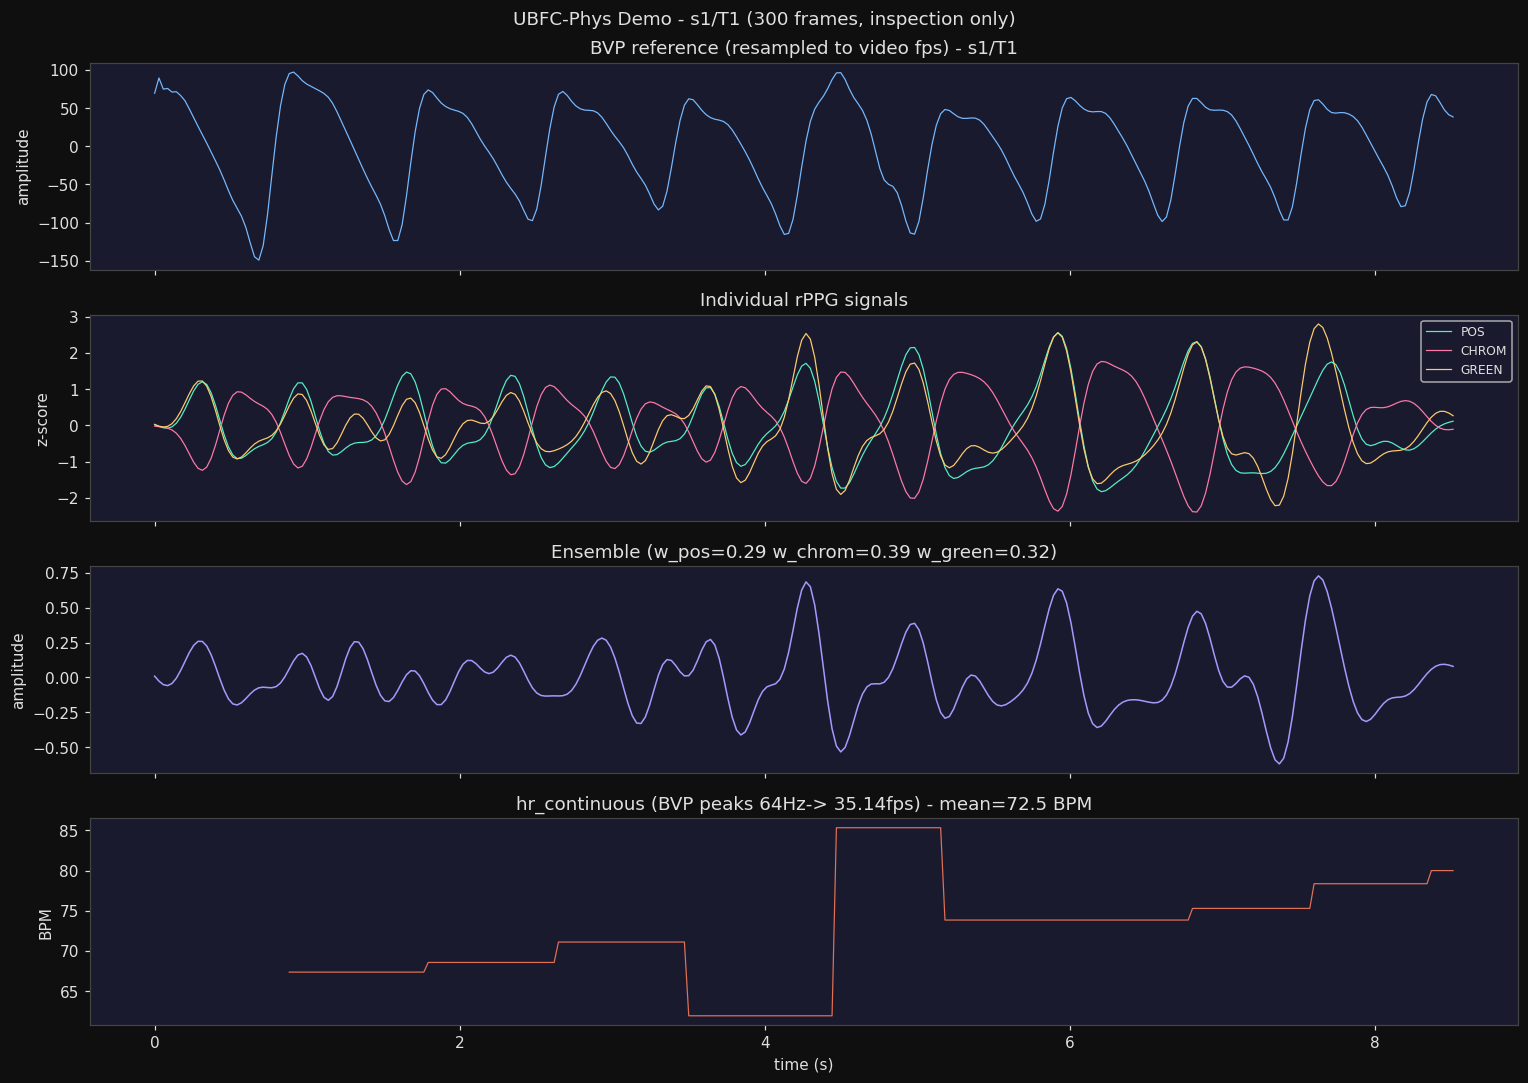


Demo complete.


In [11]:
demo_row = df_inventory[df_inventory["has_video"] & df_inventory["has_bvp"]].iloc[0]
print(f"Demo: {demo_row['subject_name']}/{demo_row['task']} | fps={demo_row['fps']:.4f}")
print()

demo_result, demo_reason = process_single_recording(demo_row, max_frames=300)

if demo_result is not None:
    print()
    print("Signal shapes:")
    for key in ["rppg_pos", "rppg_chrom", "rppg_green", "rppg_ensemble", "roi_rgb", "reference_signal", "hr_continuous", 
                "rr_intervals", "ensemble_weights"]:
        arr = demo_result.get(key)
        if arr is not None and hasattr(arr, "shape"):
            nan_c = int(np.sum(np.isnan(arr.astype(float)))) if arr.dtype != object else 0
            print(f"{key:<22} : {arr.shape} dtype={arr.dtype} nan={nan_c}")
    print()
    print("Scalar labels:")
    for key in ["hr_mean", "rmssd_ms", "sdnn_ms", "pnn50_pct", "bvp_sqi", "sqi_ensemble", "no_face_pct", "fps","n_frames", "activity_id", 
                "reference_type", "gender", "scenario", "anx_cognitive_pre", "anx_cognitive_post"]:
        print(f"{key:<24} : {demo_result.get(key, 'N/A')}")
    print()
    print("Ensemble weights:")
    for alg, w in zip(ALGORITHMS, demo_result["ensemble_weights"]):
        print(f"{alg:<6} : {w:.4f}")

    # Signal plot
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    T = len(demo_result["rppg_ensemble"])
    t = np.arange(T) / demo_result["fps"]

    axes[0].plot(t, demo_result["reference_signal"], color="#74b9ff", lw=0.8)
    axes[0].set_title(f"BVP reference (resampled to video fps) - {demo_row['subject_name']}/{demo_row['task']}")
    axes[0].set_ylabel("amplitude")

    axes[1].plot(t, demo_result["rppg_pos"], color="#55efc4", lw=0.8, label="POS")
    axes[1].plot(t, demo_result["rppg_chrom"], color="#fd79a8", lw=0.8, label="CHROM")
    axes[1].plot(t, demo_result["rppg_green"], color="#fdcb6e", lw=0.8, label="GREEN")
    axes[1].set_title("Individual rPPG signals")
    axes[1].set_ylabel("z-score")
    axes[1].legend(fontsize=8)

    w = demo_result["ensemble_weights"]
    axes[2].plot(t, demo_result["rppg_ensemble"], color="#a29bfe", lw=1.0)
    axes[2].set_title(f"Ensemble (w_pos={w[0]:.2f} w_chrom={w[1]:.2f} w_green={w[2]:.2f})")
    axes[2].set_ylabel("amplitude")

    axes[3].plot(t, demo_result["hr_continuous"], color="#e17055", lw=0.8)
    axes[3].set_title(f"hr_continuous (BVP peaks 64Hz-> 35.14fps) - mean={demo_result['hr_mean']:.1f} BPM")
    axes[3].set_ylabel("BPM")
    axes[3].set_xlabel("time (s)")

    plt.suptitle(f"UBFC-Phys Demo - {demo_row['subject_name']}/{demo_row['task']} (300 frames, inspection only)", fontsize=12)
    plt.tight_layout()

    plt.show()
    print()
    print("Demo complete.")
else:
    print(f"Demo skipped: {demo_reason}")


## 12. HDF5 Write Functions 

In [12]:
def write_recording_to_hdf5(h5_file: h5py.File, result: dict) -> bool:
    """
    Write one UBFC-Phys recording to HDF5.
    Path: subjects/{subject_name}/recordings/{task}/
    Resume-safe: returns False if group already exists.
    """
    subj = result["subject_id"]
    task = result["activity_id"]
    path = f"subjects/{subj}/recordings/{task}"

    if path in h5_file:
        return False

    grp = h5_file.require_group(path)

    for ds_name in [
        "rppg_pos", "rppg_chrom", "rppg_green", "rppg_ensemble", "ensemble_weights", "roi_rgb", "reference_signal", "hr_continuous", "rr_intervals"]:
        grp.create_dataset(ds_name, data=result[ds_name], compression="gzip", compression_opts=4)

    std_attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "dataset" : result["dataset"],
        "reference_type" : result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"] if not np.isnan(result["rmssd_ms"]) else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"]) else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "bvp_sqi" : result["bvp_sqi"],
        "sqi_pos" : result["sqi_pos"],
        "sqi_chrom" : result["sqi_chrom"],
        "sqi_green" : result["sqi_green"],
        "sqi_ensemble" : result["sqi_ensemble"],
        "no_face_pct" : result["no_face_pct"],
        "gender" : result["gender"],
        "scenario" : result["scenario"],
        "anx_cognitive_pre" : result["anx_cognitive_pre"],
        "anx_cognitive_post" : result["anx_cognitive_post"],
        "anx_somatic_pre" : result["anx_somatic_pre"],
        "anx_somatic_post" : result["anx_somatic_post"],
        "anx_confidence_pre" : result["anx_confidence_pre"],
        "anx_confidence_post" : result["anx_confidence_post"],
    }
    for key, value in std_attrs.items():
        grp.attrs[key] = value

    return True


def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Open or create ubfc_phys_ensemble.h5 in append mode.
    Top-level metadata written once on first open.
    """
    h5 = h5py.File(output_path, "a")

    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["source"] = "UBFC-Phys"
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["algorithms"] = str(ALGORITHMS)
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["bvp_bp_low"] = BVP_BP_LOW
        meta.attrs["bvp_bp_high"] = BVP_BP_HIGH
        meta.attrs["bvp_fs"] = BVP_FS
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
        meta.attrs["bvp_sqi_threshold"] = BVP_SQI_THRESHOLD
        meta.attrs["no_face_threshold"] = NO_FACE_THRESHOLD
        meta.attrs["reference_type"] = "BVP_continuous"
        meta.attrs["tasks"] = str(TASKS)
        meta.attrs["task_names"] = str(TASK_NAMES)
        meta.attrs["n_subjects_expected"] = 56
        meta.attrs["hdf5_schema"] = "subjects/{subject_name}/recordings/{task}/"
        meta.attrs["mcd_schema_compat"] = "True"
        print("HDF5 metadata group initialised.")

    return h5


print("HDF5 write functions defined.")

HDF5 write functions defined.


## 13. Full Pipeline

In [16]:
def process_all_recordings(df_inventory: pd.DataFrame, hdf5_path: str, flush_every: int = 10) -> pd.DataFrame:
    """
    Process all recordings (subjects x tasks) with safe stop/resume.
    Safe stop : create STOP_PREPROCESSING.txt in OUTPUT_DIR.
    Resume : re-run cell; already-logged (subject, task) pairs skipped in O(1).
    Crash recovery : HDF5 + log flushed every flush_every recordings.
    """
    STOP_FILE = os.path.join(OUTPUT_DIR, "STOP_PREPROCESSING.txt")
    LOG_PATH = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")

    log_rows = []
    stop_requested  = False
    processed_count = 0

    if os.path.exists(LOG_PATH) and os.path.getsize(LOG_PATH) > 0:
        df_existing = pd.read_csv(LOG_PATH)
        log_rows = df_existing.to_dict("records")
        existing_keys = set(zip(df_existing["subject"].astype(str), df_existing["task"].astype(str)))
        print(f"Resuming - {len(log_rows)} log entries from previous run.")
    else:
        existing_keys = set()
        print("Starting fresh run.")

    df_todo = df_inventory[df_inventory["has_video"] & df_inventory["has_bvp"]]
    total = len(df_todo)

    already_done = sum(1 for _, row in df_todo.iterrows() if (row["subject_name"], row["task"]) in existing_keys)
    if already_done > 0:
        print(f"Resume: {already_done}/{total} already logged - skipping.")
    print()
    print(f"To stop safely: create {STOP_FILE}")
    print(f"Pipeline stops after current recording completes.")
    print()

    try:
        with initialise_hdf5(hdf5_path) as h5:
            for i, (_, row) in enumerate(df_todo.iterrows()):
                subject = row["subject_name"]
                task = row["task"]
                key = (subject, task)

                if os.path.exists(STOP_FILE):
                    print()
                    print(f"Stop file detected at [{i+1}/{total}] {subject}/{task}")
                    print("Flushing HDF5 and saving log...")
                    stop_requested = True
                    break

                if key in existing_keys:
                    continue

                hdf5_grp = f"subjects/{subject}/recordings/{task}"
                if hdf5_grp in h5:
                    log_rows.append({
                        "subject" : subject,
                        "task" : task,
                        "status" : "resumed", 
                        "skip_reason" : "already_in_hdf5",
                        "hr_mean" : np.nan, 
                        "fps" : row["fps"],
                        "bvp_sqi" : np.nan, 
                        "sqi_pos" : np.nan,
                        "sqi_chrom" : np.nan, 
                        "sqi_green" : np.nan,
                        "sqi_ensemble" : np.nan, 
                        "n_frames" : 0,
                        "no_face_pct" : np.nan, 
                        "rmssd_ms" : np.nan,
                        "gender" : np.nan, 
                        "scenario" : np.nan,
                    })
                    existing_keys.add(key)
                    continue

                if (i + 1) % 15 == 0 or i == 0:
                    n_proc = sum(1 for r in log_rows if r.get("status") == "processed")
                    pct = (i + 1) / total * 100
                    print(f"[{i+1:03d}/{total}] {pct:.1f}% processed this session: {processed_count} total in log: {n_proc}")

                print(f"[{i+1:03d}/{total}] {subject}/{task}", end="  ")
                result, reason = process_single_recording(row)

                if result is not None:
                    write_recording_to_hdf5(h5, result)
                    processed_count += 1
                    log_rows.append({
                        "subject" : subject,
                        "task" : task,
                        "status" : "processed",
                        "skip_reason" : "ok",
                        "hr_mean" : result["hr_mean"],
                        "fps" : result["fps"],
                        "bvp_sqi" : result["bvp_sqi"],
                        "sqi_pos" : result["sqi_pos"],
                        "sqi_chrom" : result["sqi_chrom"],
                        "sqi_green" : result["sqi_green"],
                        "sqi_ensemble" : result["sqi_ensemble"],
                        "w_pos" : float(result["ensemble_weights"][0]),
                        "w_chrom" : float(result["ensemble_weights"][1]),
                        "w_green" : float(result["ensemble_weights"][2]),
                        "n_frames" : result["n_frames"],
                        "no_face_pct" : result["no_face_pct"],
                        "rmssd_ms" : result["rmssd_ms"],
                        "gender" : result["gender"],
                        "scenario" : result["scenario"],
                    })
                    existing_keys.add(key)

                    if processed_count % flush_every == 0:
                        h5.flush()
                        pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False)
                        print(f"[flush] HDF5 + log saved ({processed_count} new this session)")

                else:
                    print(f"SKIPPED — {reason}")
                    log_rows.append({
                        "subject" : subject, 
                        "task" : task,
                        "status" : "skipped", 
                        "skip_reason" : reason,
                        "hr_mean" : np.nan, 
                        "fps" : row["fps"],
                        "bvp_sqi" : np.nan, 
                        "sqi_pos" : np.nan,
                        "sqi_chrom" : np.nan, 
                        "sqi_green" : np.nan,
                        "sqi_ensemble" : np.nan, 
                        "n_frames" : 0,
                        "no_face_pct" : np.nan, 
                        "rmssd_ms" : np.nan,
                        "gender" : np.nan, 
                        "scenario" : np.nan,
                    })
                    existing_keys.add(key)

            h5.flush()

    except KeyboardInterrupt:
        print()
        print("KeyboardInterrupt - HDF5 closed safely.")
        print(f"Processed {processed_count} recordings this session.")

    df_log = pd.DataFrame(log_rows) if log_rows else pd.DataFrame(
        columns=["subject", "task", "status", "skip_reason", "hr_mean", "fps", "bvp_sqi", "sqi_pos", "sqi_chrom", "sqi_green", "sqi_ensemble", 
                 "n_frames", "no_face_pct", "rmssd_ms", "gender", "scenario"])
    df_log.to_csv(LOG_PATH, index=False)

    print()
    print("=" * 60)
    if stop_requested:
        print("Pipeline stopped safely - safe to shut down.")
        print(f"Delete {STOP_FILE} before resuming.")
    else:
        print("Processing complete.")
    print("=" * 60)

    processed = (df_log["status"] == "processed").sum() if len(df_log) else 0
    skipped = (df_log["status"] == "skipped").sum() if len(df_log) else 0
    resumed = (df_log["status"] == "resumed").sum() if len(df_log) else 0
    print(f"Total processed : {processed}")
    print(f"Total skipped : {skipped}")
    print(f"Total resumed : {resumed}")
    print(f"This session : {processed_count} new recordings written")
    print()

    if skipped > 0:
        print("Skip reasons:")
        reasons = (df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts())
        for r, c in reasons.items():
            print(f"{r:<35} : {c}")
    print()

    print("Per-task pass rate:")
    for task in TASKS:
        sub = df_log[df_log["task"] == task]
        n_proc = (sub["status"] == "processed").sum()
        print(f"{task}  {n_proc}/{len(sub)} ({n_proc/max(len(sub),1)*100:.1f}%) [{TASK_NAMES[task]}]")
    print()
    print(f"Log : {LOG_PATH}")
    print(f"HDF5 : {hdf5_path}")
    return df_log


print("Full pipeline ready.")
print(f"Total recordings to process : {(df_inventory['has_video'] & df_inventory['has_bvp']).sum()}")
print()
df_log = process_all_recordings(df_inventory, HDF5_PATH)

Full pipeline ready.
Total recordings to process : 168

Resuming - 147 log entries from previous run.
Resume: 147/168 already logged - skipping.

To stop safely: create E:/QualityPhys\STOP_PREPROCESSING.txt
Pipeline stops after current recording completes.

[148/168] s50/T1  s50/T1 T=6325 HR=103.3 bvp_sqi=0.951 ens=0.208 [pos=0.229 chrom=0.206 green=0.171] no_face=0.0% fps=35.14
[149/168] s50/T2  SKIPPED — ensemble_sqi_low (0.043)
[150/168] 89.3% processed this session: 1 total in log: 127
[150/168] s50/T3  s50/T3 T=6325 HR=101.9 bvp_sqi=0.805 ens=0.080 [pos=0.263 chrom=0.238 green=0.070] no_face=0.0% fps=35.14
[151/168] s51/T1  s51/T1 T=6325 HR=63.3 bvp_sqi=0.872 ens=0.250 [pos=0.359 chrom=0.353 green=0.275] no_face=0.0% fps=35.14
[152/168] s51/T2  s51/T2 T=6325 HR=67.3 bvp_sqi=0.682 ens=0.084 [pos=0.059 chrom=0.050 green=0.090] no_face=0.0% fps=35.14
[153/168] s51/T3  s51/T3 T=6325 HR=72.3 bvp_sqi=0.807 ens=0.067 [pos=0.130 chrom=0.123 green=0.083] no_face=0.0% fps=35.14
[154/168] s5

## 14. Post-Processing Validation

Top-level groups : ['metadata', 'subjects']

Metadata:
algorithms : ['pos', 'chrom', 'green']
bvp_bp_high : 8.0
bvp_bp_low : 0.5
bvp_fs : 64.0
bvp_sqi_threshold : 0.5
dataset_name : ubfc_phys_ensemble
hdf5_schema : subjects/{subject_name}/recordings/{task}/
mcd_schema_compat : True
n_subjects_expected : 56
no_face_threshold : 20.0
preprocessing_version : 1.0
reference_type : BVP_continuous
rppg_bp_high : 3.5
rppg_bp_low : 0.7
rppg_sqi_threshold : 0.05
source : UBFC-Phys
task_names : {'T1': 'rest', 'T2': 'speech_stress', 'T3': 'arithmetic_stress'}
tasks : ['T1', 'T2', 'T3']

Subject coverage : 56 / 56 expected (0 pending download)
Total recordings : 144 / 168 for 56 subjects
[WARN] 24 recordings missing - check skip log

HR by task (expect T2/T3 > T1 rest):
      mean   std   min    max
task                         
T1    81.6  12.0  48.8  103.3
T2    77.7   7.8  65.0   96.8
T3    79.1   8.8  64.9  101.9

n_frames distribution:
range : 6324 - 6325
mean : 6325

SQI distributions:
POS    

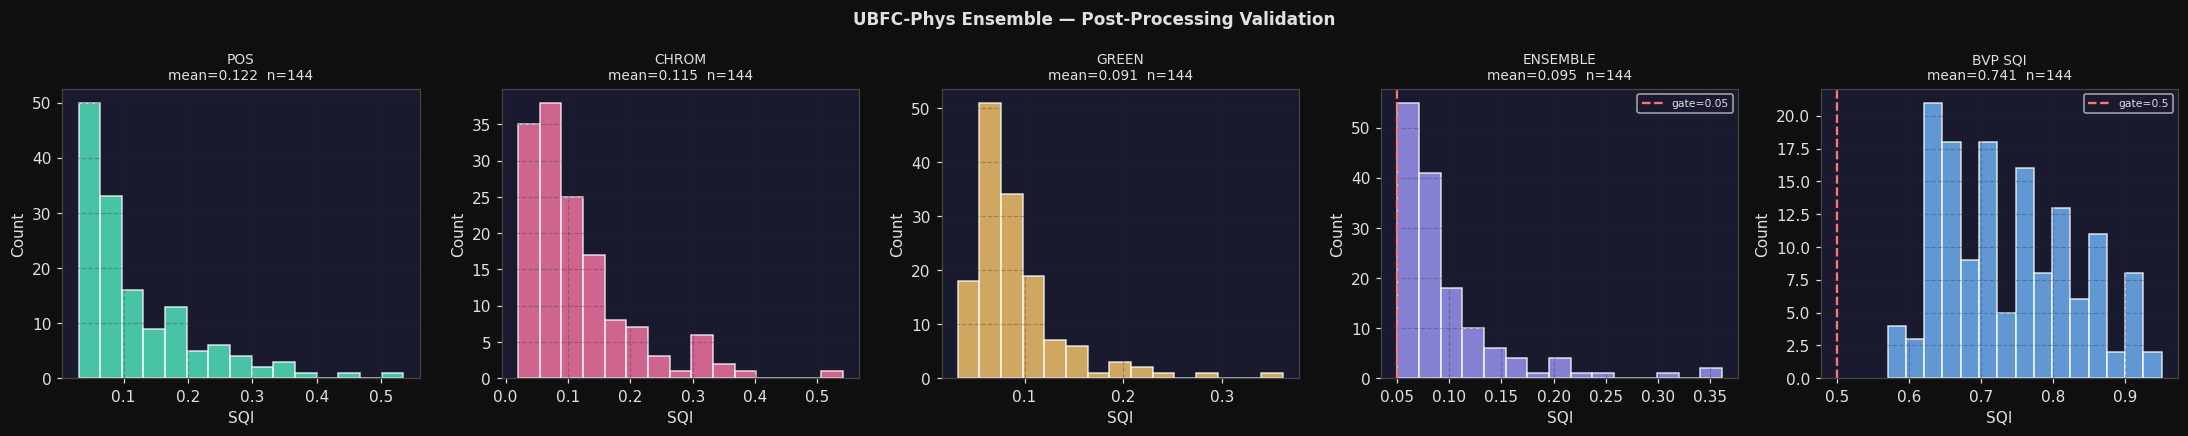

In [17]:
def validate_hdf5(hdf5_path: str) -> pd.DataFrame:
    """
    Post-processing validation for ubfc_phys_ensemble.h5.
    Checks: metadata, shape consistency, ensemble weights, HR by task,
    SQI distributions, HRV sanity, subject metadata, no_face outliers.
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups : {list(h5.keys())}")
        print()
        print("Metadata:")
        for key, val in h5["metadata"].attrs.items():
            print(f"{key} : {val}")
        print()

        subjects_sorted = sorted(h5["subjects"].keys(), key=lambda x: int(x[1:]))
        for subj_key in subjects_sorted:
            for task_key in sorted(h5[f"subjects/{subj_key}/recordings"].keys()):
                grp = h5[f"subjects/{subj_key}/recordings/{task_key}"]
                attrs = dict(grp.attrs)

                T = grp["rppg_ensemble"].shape[0]
                for ds in ["rppg_pos", "rppg_chrom", "rppg_green", "reference_signal", "hr_continuous"]:
                    assert grp[ds].shape[0] == T, f"{ds} mismatch in {subj_key}/{task_key}: {grp[ds].shape[0]} vs {T}"

                weights = grp["ensemble_weights"][:]
                w_sum = float(weights.sum())
                assert abs(w_sum - 1.0) < 1e-4, f"{subj_key}/{task_key}: ensemble weights sum={w_sum:.4f}"

                records.append({
                    "subject" : subj_key,
                    "task" : task_key,
                    "n_frames" : T,
                    "fps" : attrs.get("fps"),
                    "hr_mean" : attrs.get("hr_mean"),
                    "rmssd_ms" : attrs.get("rmssd_ms"),
                    "bvp_sqi" : attrs.get("bvp_sqi"),
                    "sqi_pos" : attrs.get("sqi_pos"),
                    "sqi_chrom" : attrs.get("sqi_chrom"),
                    "sqi_green" : attrs.get("sqi_green"),
                    "sqi_ensemble" : attrs.get("sqi_ensemble"),
                    "w_pos" : float(weights[0]),
                    "w_chrom" : float(weights[1]),
                    "w_green" : float(weights[2]),
                    "no_face_pct" : attrs.get("no_face_pct"),
                    "n_beats" : grp["rr_intervals"].shape[0],
                    "gender" : attrs.get("gender"),
                    "scenario" : attrs.get("scenario"),
                    "anx_cog_pre" : attrs.get("anx_cognitive_pre"),
                    "anx_cog_post" : attrs.get("anx_cognitive_post"),
                })

    df = pd.DataFrame(records)
    n_subjects = df["subject"].nunique()

    print("=" * 60)
    print(f"Subject coverage : {n_subjects} / 56 expected ({56 - n_subjects} pending download)")
    print(f"Total recordings : {len(df)} / {n_subjects * 3} for {n_subjects} subjects")
    missing = n_subjects * 3 - len(df)
    if missing > 0:
        print(f"[WARN] {missing} recordings missing - check skip log")
    print()

    print("HR by task (expect T2/T3 > T1 rest):")
    print(df.groupby("task")["hr_mean"].agg(["mean","std","min","max"]).round(1).to_string())
    print()

    print("n_frames distribution:")
    print(f"range : {df['n_frames'].min()} - {df['n_frames'].max()}")
    print(f"mean : {df['n_frames'].mean():.0f}")
    print()

    print("SQI distributions:")
    for col, label, gate in [
        ("sqi_pos", "POS", None),
        ("sqi_chrom", "CHROM", None),
        ("sqi_green", "GREEN", None),
        ("sqi_ensemble","ENSEMBLE", RPPG_SQI_THRESHOLD),
        ("bvp_sqi", "BVP SQI", BVP_SQI_THRESHOLD),
    ]:
        s = df[col].dropna()
        gate_str = f"gate={gate} below_gate={(s < gate).sum()}" if gate else ""
        print(f"{label:<12} : mean={s.mean():.3f}  min={s.min():.3f}  max={s.max():.3f}{gate_str}")
    print()

    print("Ensemble weights (mean across recordings):")
    for alg, col in zip(ALGORITHMS, ["w_pos", "w_chrom", "w_green"]):
        w = df[col].dropna()
        print(f"{alg:<8}: mean={w.mean():.3f}  std={w.std():.3f}  min={w.min():.3f}  max={w.max():.3f}")
    print()

    print("HRV label sanity:")
    rmssd_valid = df["rmssd_ms"].replace(-1.0, np.nan).dropna()
    print(f"RMSSD range : {rmssd_valid.min():.1f} - {rmssd_valid.max():.1f} ms")
    print(f"Sentinel -1.0: {(df['rmssd_ms'] == -1.0).sum()} recordings")
    print()

    print("Subject metadata completeness:")
    print(f"gender missing : {(df['gender'] == '?').sum()}")
    print(f"scenario missing : {(df['scenario'] == '?').sum()}")
    print(f"anxiety missing : {(df['anx_cog_pre'] == -1.0).sum()}")
    print()
    dedup = df.drop_duplicates("subject")
    print("Gender distribution :", dedup["gender"].value_counts().to_dict())
    print("Scenario distribution:", dedup["scenario"].value_counts().to_dict())
    print()

    bad_face = df[df["no_face_pct"] > 1.0].sort_values("no_face_pct", ascending=False)
    if len(bad_face):
        print(f"no_face > 1% ({len(bad_face)} recordings):")
        print(bad_face[["subject","task","no_face_pct","n_frames"]].to_string(index=False))
    else:
        print("no_face outliers : none")
    print()

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle("UBFC-Phys Ensemble — Post-Processing Validation",
                 fontsize=11, fontweight="bold")
    plot_data = [
        ("sqi_pos", "POS", "#55efc4", None),
        ("sqi_chrom", "CHROM", "#fd79a8", None),
        ("sqi_green", "GREEN", "#fdcb6e", None),
        ("sqi_ensemble","ENSEMBLE", "#a29bfe", RPPG_SQI_THRESHOLD),
        ("bvp_sqi", "BVP SQI", "#74b9ff", BVP_SQI_THRESHOLD),
    ]
    for ax, (col, label, color, gate) in zip(axes, plot_data):
        s = df[col].dropna()
        ax.hist(s, bins=15, color=color, alpha=0.8, edgecolor="white")
        if gate is not None:
            ax.axvline(gate, color="#ff7675", ls="--", lw=1.5, label=f"gate={gate}")
            ax.legend(fontsize=7)
        ax.set_title(f"{label}\nmean={s.mean():.3f}  n={len(s)}", fontsize=9)
        ax.set_xlabel("SQI")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return df

df_validation = validate_hdf5(HDF5_PATH)